# **Darált Dokumentumok (SOLUTION)**

<div style="font-size: 14px; color: #6e8192; line-height: 1.5;">
  <div style="display: flex; align-items: center; gap: 5px; margin-bottom: 5px;">
    <span style="font-size: 18px; color: #6e8192;">🎯</span>
    <span>MI Országos Diákolimpia, Nyári Válogató</span>
  </div>
  <div style="display: flex; align-items: center; gap: 5px;">
    <span style="font-size: 18px; color: #6e8192;">👁️</span>
    <span>Computer Vision: Solution Notebook</span>
  </div>
  <div style="display: flex; align-items: center; gap: 5px;">
    <span style="font-size: 18px; color: #6e8192;">🏆</span>
    <span>100 pont (30 + 10 + 25 + 25 + 10)</span>
  </div>
  <div style="display: flex; align-items: center; gap: 5px;">
    <span style="font-size: 18px; color: #6e8192;">🗓️</span>
    <span>2026. május</span>
  </div>
</div>

> **Figyelem:** ez a notebook a **szervezői/oktatási referencia** változat. A cellák tartalmazzák a rekonstruált dokumentumokból levezetett **gyanúsítotti listát** (`SUSPECTS` cella, 7 név + polgár-ID), valamint a teljes nyomozati pipeline-t: felismerő-modell előfeldolgozás, csere-azonosítás és visszatérő-megfigyelő keresés. Ezek a versenyzői (RAW) notebookban **nincsenek megadva**, a versenyzőknek maguknak kell levezetniük a rekonstruált dokumentumokból és a CCTV-predikciókból. A notebook célja, hogy a szervezők számára kalibrálni tudják a scoring-ot, és összevethető legyen a contestant-pipeline a referenciával.

Az utolsó kérdést (**„Ki az értelmi szerző?”**) szándékosan nyitva hagyjuk megoldás nélkül; a választ a 3. szakasz visszatérő-megfigyelő találatából kell levezetni.


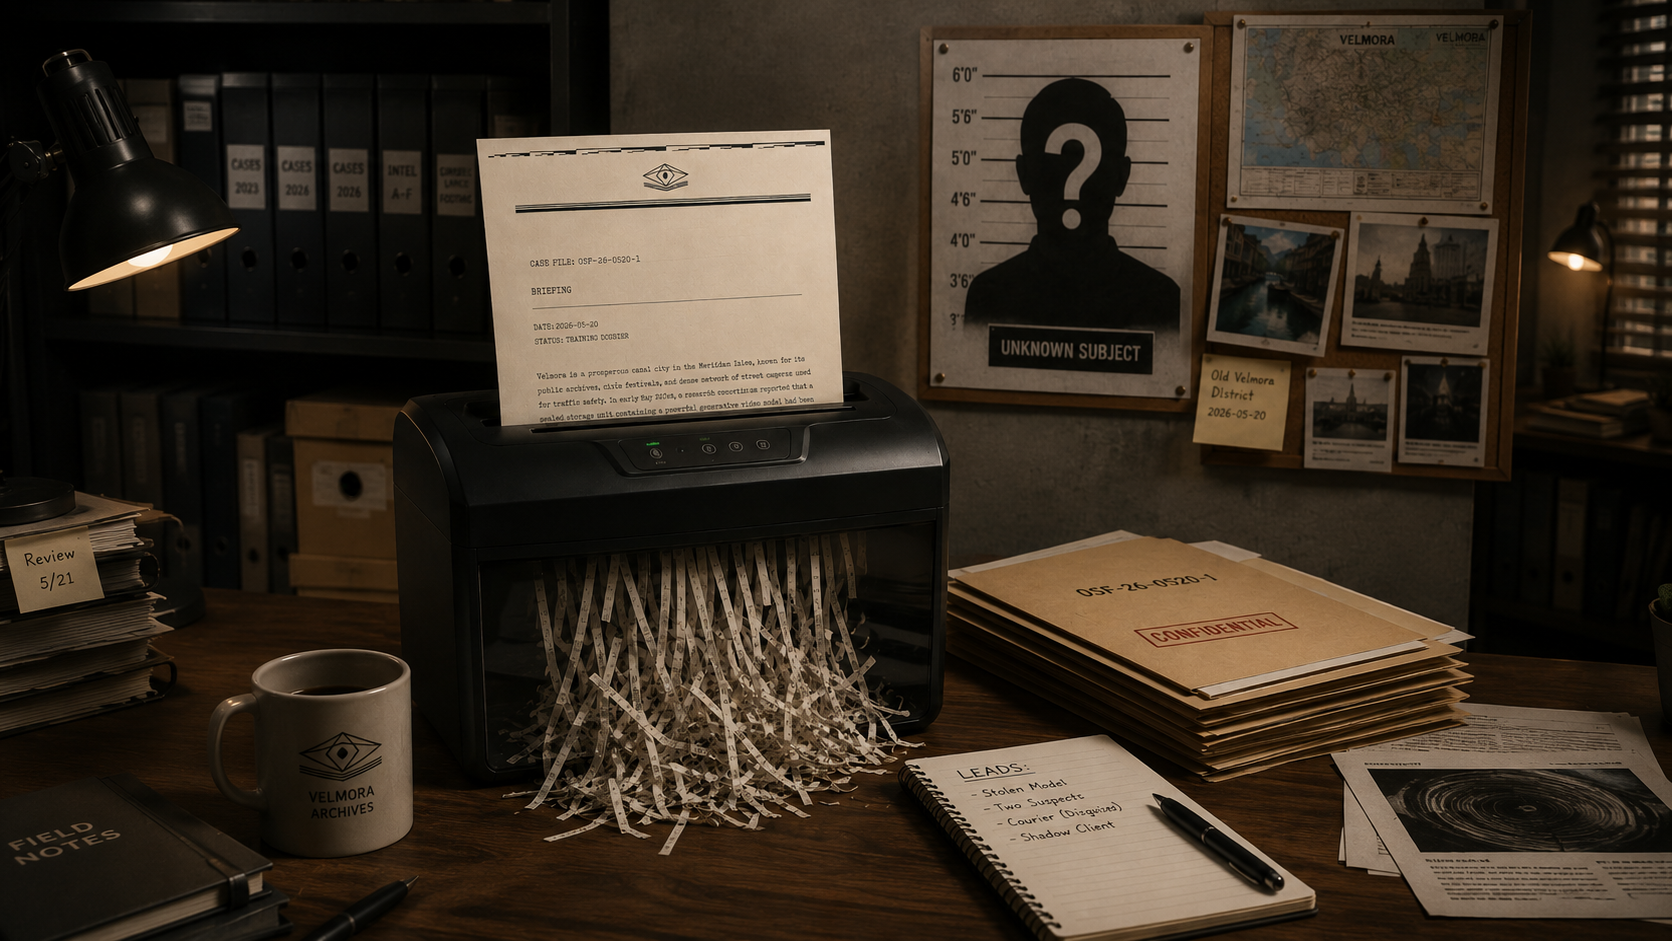

## **Adat-feltevések**

A notebook a flatten-elt `data/` mappastruktúrát várja:

```text
data/
  shreds/                          # 1922 .png darált csík
  cctv/                            # CCTV képek (.png) + bounding box-ok (.csv)
  background_briefing.png
  background_suspect_list.png
  background_citizen_list.png
  briefing_page1_with_barcode.png
  best_citizen_face_model.pt       # polgár-felismerő modell súlyai
```

A CCTV `.csv` fájlok minimum ezeket az oszlopokat tartalmazzák:

```text
left, top, right, bottom
```

(Némely változatban egy `index` oszlop is van ground-truth címkével; ha jelen van, a notebook egy konzisztencia-ellenőrzést is futtat.)

## **Beállítások és importok**

In [ ]:
# Opcionális telepítések tiszta környezethez.
# Csak akkor futtasd, ha hiányoznak a csomagok.
# %pip install numpy pillow matplotlib pandas torch scipy

In [ ]:
from pathlib import Path
from itertools import combinations
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F

In [ ]:
DATA_DIR         = Path("data")
SHREDS_DIR       = DATA_DIR / "shreds"
CCTV_DIR         = DATA_DIR / "cctv"
MODEL_CHECKPOINT = DATA_DIR / "best_citizen_face_model.pt"
OUTPUT_DIR       = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print("SHREDS_DIR:",       SHREDS_DIR)
print("CCTV_DIR:",         CCTV_DIR)
print("MODEL_CHECKPOINT:", MODEL_CHECKPOINT)

## **Adathalmaz letöltése (szervezői)**

Szervezőként ugyanazokat a fájlokat töltjük le, mint amit a versenyzők is megkapnak: nincs privilegizált adat ezen a feladaton, a megoldás a versenyzői pipeline-on alapul.

Ha a `data/` mappa már fel van populálva (pl. lokálisan generált adat), a cella átugorja a letöltést.

In [ ]:
import os
import subprocess
import sys
import zipfile

DATA_DIR.mkdir(exist_ok=True)

FILES = {
    "data_documents.zip":         "1jG4yj_SM5Zw-697iRMHKWKkvmI10DrLq",   # shreds/ + background_*.png + briefing_*.png
    "data_cctv.zip":              "1EBQ84SY8Cgumz8AGNNA1vBXa760BGYtT",   # cctv/ képek és csv-k
    "best_citizen_face_model.pt": "13iu5uFyXk56-jgemHZxgmojsg18WoTOi",   # polgár-felismerő modell
}

EXTRACT_TARGETS = {
    "data_documents.zip": DATA_DIR,
    "data_cctv.zip":      DATA_DIR,
}

MOVE_TARGETS = {
    "best_citizen_face_model.pt": MODEL_CHECKPOINT,
}

SENTINELS = [SHREDS_DIR, CCTV_DIR, MODEL_CHECKPOINT]

if all(p.exists() for p in SENTINELS):
    print("A data/ mappa már populálva, letöltés kihagyva.")
else:
    try:
        import gdown  # type: ignore
    except ImportError:
        try:
            subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gdown"], check=True)
            import gdown  # type: ignore
        except Exception:
            gdown = None  # type: ignore

    if gdown is None:
        print("gdown nem elérhető. Töltsd le kézzel:\n")
        for name, file_id in FILES.items():
            print(f"  https://drive.google.com/uc?id={file_id}  ->  {name}")
    else:
        for name, file_id in FILES.items():
            if Path(name).exists():
                continue
            try:
                gdown.download(id=file_id, output=name, quiet=False)
            except Exception as e:
                print(f"  {name} letöltése sikertelen: {e}")

        for zip_name, target in EXTRACT_TARGETS.items():
            if Path(zip_name).exists():
                with zipfile.ZipFile(zip_name, "r") as zf:
                    zf.extractall(target)

        for src_name, dst in MOVE_TARGETS.items():
            if Path(src_name).exists() and not dst.exists():
                Path(src_name).rename(dst)

for p in SENTINELS:
    print(f"  {p}: {'OK' if p.exists() else 'HIÁNYZIK'}")

## **Szakasz 1: Darált dokumentumok rekonstrukciója és a gyanúsítottak azonosítása**

A dokumentumokat **20 px széles csíkokra** vágták. Minden csíkon felül egy barkód-szerű artifact található.
A barkód magassága **44 px**, **11 vízszintes bit**-ből áll, mindegyik **4 px**-en ismétlődik.

A háttérszín alapján szétválaszthatók a források:

| Dokumentum | Várt csíkok | Oldalak | Háttér RGB |
|---|---:|---:|---|
| eligazítás | 62 | 1 | `(253, 247, 232)` |
| gyanúsítotti lista | 124 | 2 | `(253, 232, 232)` |
| polgárlista | 1736 | 28 | `(235, 253, 232)` |

A megoldás háttérszín alapján csoportosítja a csíkokat, a barkódot a legközelebbi bináris mintával dekódolja, rekonstruálja az oldalakat, és kiírja őket az `outputs/reconstructed_documents/` mappába.

In [ ]:
STRIP_WIDTH        = 20
STRIPS_PER_PAGE    = 62
BARCODE_BITS       = 11
BARCODE_BIT_HEIGHT = 4
BARCODE_HEIGHT     = BARCODE_BITS * BARCODE_BIT_HEIGHT

DOCUMENT_SPECS = {
    "briefing": {
        "background_rgb": (253, 247, 232),
        "strip_count": 62,
        "pages": 1,
    },
    "suspect_list": {
        "background_rgb": (253, 232, 232),
        "strip_count": 124,
        "pages": 2,
    },
    "citizen_list": {
        "background_rgb": (235, 253, 232),
        "strip_count": 1736,
        "pages": 28,
    },
}

In [ ]:
paths  = sorted(SHREDS_DIR.glob("*.png"))
images = [Image.open(path).convert("RGB") for path in paths]
strips = np.stack([np.asarray(image) for image in images], axis=0)

In [ ]:
# Polgárlista csíkok háttérszín-maszk: (235, 253, 232)
first_document_mask = (strips[:,:,:,0] == 235) & (strips[:,:,:,1] == 253) & (strips[:,:,:,2] == 232)
first_document_mask = np.any(first_document_mask, axis=(1,2))
print(np.count_nonzero(first_document_mask))
first_document_mask.shape

In [ ]:
# Gyanúsítotti lista csíkok háttérszín-maszk: (253, 232, 232)
second_document_mask = (strips[:,:,:,0] == 253) & (strips[:,:,:,1] == 232) & (strips[:,:,:,2] == 232)
second_document_mask = np.any(second_document_mask, axis=(1,2))
print(np.count_nonzero(second_document_mask))
second_document_mask.shape

In [ ]:
# Eligazítás csíkok háttérszín-maszk: (253, 247, 232)
third_document_mask = (strips[:,:,:,0] == 253) & (strips[:,:,:,1] == 247) & (strips[:,:,:,2] == 232)
third_document_mask = np.any(third_document_mask, axis=(1,2))
print(np.count_nonzero(third_document_mask))
third_document_mask.shape

In [ ]:
# 1736 lehetséges bináris pozíció-kód a polgárlistához (28 oldal × 62 csík).
max_bin_repr_0 = np.array([list(map(float, list(np.binary_repr(i, width=11)))) for i in range(1736)])
print(max_bin_repr_0.shape)
reshaped_max_bin_repr_0 = np.broadcast_to(max_bin_repr_0[:,:,None], (1736, 11, 4)).reshape(1736, 44)
reshaped_max_bin_repr_0[2]

In [ ]:
# 124 lehetséges bináris pozíció-kód a gyanúsítotti listához (2 oldal × 62 csík).
max_bin_repr_1 = np.array([list(map(float, list(np.binary_repr(i, width=11)))) for i in range(124)])
max_bin_repr_1.shape
reshaped_max_bin_repr_1 = np.broadcast_to(max_bin_repr_1[:,:,None], (124, 11, 4)).reshape(124, 44)
reshaped_max_bin_repr_1[2]

In [ ]:
# 62 lehetséges bináris pozíció-kód az eligazításhoz (1 oldal × 62 csík).
max_bin_repr_2 = np.array([list(map(float, list(np.binary_repr(i, width=11)))) for i in range(62)])
print(max_bin_repr_2.shape)
reshaped_max_bin_repr_2 = np.broadcast_to(max_bin_repr_2[:,:,None], (62, 11, 4)).reshape(62, 44)
reshaped_max_bin_repr_2.shape

In [ ]:
# Eligazítás rekonstruálása: a csík barkód-szeletének és minden lehetséges
# bináris kódnak az L1-távolsága; a legkisebb adja a csík pozícióját.
distance = np.sum(np.abs(strips[third_document_mask][:,:44,0,0]/255.0 - reshaped_max_bin_repr_2[:, None,:]), axis=2)
plt.imshow(distance, cmap='hot', interpolation='nearest')
plt.colorbar()

print(distance.shape)

indices = np.argmin(distance, axis=1)
np.concatenate((strips[third_document_mask][indices]), axis=1)
Image.fromarray(np.concatenate((strips[third_document_mask][indices[::-1]]), axis=1)).show()

In [ ]:
# Gyanúsítotti lista rekonstruálása: L2-távolság a barkód-szelet és a bináris kódok között.
distance = np.sum(np.pow(strips[second_document_mask][:,:44,0,0]/255.0 - reshaped_max_bin_repr_1[:, None,:], 2), axis=2)
plt.imshow(distance, cmap='hot', interpolation='nearest')
plt.colorbar()

indices = np.argmin(distance, axis=1)
np.concatenate((strips[second_document_mask][indices]), axis=1)
Image.fromarray(np.concatenate((strips[second_document_mask][indices[::-1]]), axis=1)).show()

In [ ]:
# Polgárlista rekonstruálása: L2-távolság a barkód-szelet és a bináris kódok között.
distance = np.sum(np.pow(strips[first_document_mask][:,:44,0,0]/255.0 - reshaped_max_bin_repr_0[:, None,:], 2), axis=2)
plt.imshow(distance, cmap='hot', interpolation='nearest')
plt.colorbar()

indices = np.argmin(distance, axis=1)
np.concatenate((strips[first_document_mask][indices]), axis=1)
Image.fromarray(np.concatenate((strips[first_document_mask][indices[::-1]]), axis=1)).show()

### **Szakasz 1 várt eredmény: kinyert gyanúsítottak**

A gyanúsítotti lista rekonstruálása és a kezdőbetű + vezetéknév összevetése a polgárlistával a következő gyanúsított-osztálycímkéket adja:

In [ ]:
SUSPECTS = pd.DataFrame([
    {"id": 4,  "first_name": "Elliot", "last_name": "Altman"},
    {"id": 9,  "first_name": "Lora",   "last_name": "Bennett"},
    {"id": 14, "first_name": "Victor", "last_name": "Carlton"},
    {"id": 18, "first_name": "Carla",  "last_name": "Devane"},
    {"id": 25, "first_name": "Sora",   "last_name": "Finch"},
    {"id": 59, "first_name": "Marcus", "last_name": "Manson"},
    {"id": 84, "first_name": "Nolan",  "last_name": "Smith"},
])
SUSPECTS["name"]      = SUSPECTS["first_name"] + " " + SUSPECTS["last_name"]
SUSPECT_IDS           = set(SUSPECTS["id"].tolist())
ID_TO_SUSPECT_NAME    = dict(zip(SUSPECTS["id"], SUSPECTS["name"]))

SUSPECTS

## **Szakasz 2: CCTV kivágatok helyes átadása a polgár-osztályozónak**

Ez a feladat **leghibakvázbb része**. Ha a kivágat rosszul kerül a hálóba, a modell magabiztosan, de tévesen osztályoz.

Szükséges előfeldolgozás:

1. Vedd a bounding box-ot a CCTV `.csv` fájlból.
2. Vágd ki **csak a felső / arc-részt** a bounding boxból, ne a teljes testet.
3. Konvertáld a kivágatot RGB-be.
4. Méretezd át pontosan `64 × 64`-re.
5. Konvertáld a kép-elrendezést `HWC`-ből `CHW`-be.
6. Adj hozzá batch dimenziót: `CHW -> NCHW`.
7. Float32 típus.
8. Pixelek skálázása `[0, 255]`-ből `[0, 1]`-be.
9. Normalizálás `[-1, 1]`-be `(x - 0.5) / 0.5`-tel.
10. Mozgasd a tensort a modellel azonos device-ra.
11. Használj `model.eval()`-et és `torch.inference_mode()`-ot.
12. A predikált osztály `argmax(logits) + 1`, mert a polgár-ID-k 1-indexeltek, a PyTorch osztály-indexek viszont 0-indexeltek.

**Ne** forgasd vagy tükrözd a CCTV kivágatokat. Ebben az adathalmazban a polgárok mindig balra néznek.

In [ ]:
class ConvBNAct(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, stride=1, groups=1):
        super().__init__()
        padding = kernel_size // 2
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size, stride=stride, padding=padding, groups=groups, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.SiLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class DSConv(nn.Module):
    """Depthwise separable convolution blokk."""
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.net = nn.Sequential(
            ConvBNAct(in_ch, in_ch, kernel_size=3, stride=stride, groups=in_ch),
            ConvBNAct(in_ch, out_ch, kernel_size=1, stride=1, groups=1),
        )

    def forward(self, x):
        return self.net(x)


class CitizenEmbeddingNet(nn.Module):
    def __init__(self, num_classes: int, emb_dim: int = 128):
        super().__init__()
        self.features = nn.Sequential(
            ConvBNAct(3, 32, stride=2),      # 64 -> 32
            DSConv(32, 64, stride=1),
            DSConv(64, 96, stride=2),        # 32 -> 16
            DSConv(96, 128, stride=1),
            DSConv(128, 192, stride=2),      # 16 -> 8
            DSConv(192, 256, stride=1),
            DSConv(256, 320, stride=2),      # 8 -> 4
            nn.AdaptiveAvgPool2d(1),
        )
        self.embedding = nn.Sequential(
            nn.Flatten(),
            nn.Linear(320, emb_dim),
            nn.LayerNorm(emb_dim),
            nn.SiLU(inplace=True),
        )
        self.classifier = nn.Linear(emb_dim, num_classes)

    def forward(self, x, return_embedding: bool = False):
        z        = self.features(x)
        emb      = self.embedding(z)
        emb_norm = F.normalize(emb, p=2, dim=1)
        logits   = self.classifier(emb_norm)
        if return_embedding:
            return logits, emb_norm
        return logits

In [ ]:
def load_citizen_model(checkpoint_path: Path = MODEL_CHECKPOINT, num_classes: int = 108, emb_dim: int = 128):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model  = CitizenEmbeddingNet(num_classes=num_classes, emb_dim=emb_dim).to(device)

    if device.type == "cuda":
        model = model.to(memory_format=torch.channels_last)

    checkpoint = torch.load(checkpoint_path, map_location=device)
    if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        model.load_state_dict(checkpoint["model_state_dict"])
    else:
        model.load_state_dict(checkpoint)

    model.eval()
    return model, device


model, DEVICE = load_citizen_model()
print("Device:", DEVICE)
print("Tanítható paraméterek:", sum(p.numel() for p in model.parameters() if p.requires_grad))

In [ ]:
def crop_face_from_bbox(image: Image.Image, left, top, right, bottom) -> Image.Image:
    """
    Kivágja az arc / felsőtest régiót, amit a tanított háló elvár.

    A teljes bounding box a teljes test. A tanított osztályozó a felső részt várja.
    Az eredeti megoldás: bottom - (bottom - top) // 1.5.
    """
    left, top, right, bottom = map(float, [left, top, right, bottom])
    height      = bottom - top
    face_bottom = bottom - (height / 1.5)
    return image.crop((left, top, right, face_bottom)).convert("RGB")


def preprocess_crop(crop: Image.Image, device: torch.device = DEVICE) -> torch.Tensor:
    """PIL kivágatot a CitizenEmbeddingNet által elvárt tensor formátumba alakít."""
    resized = crop.resize((64, 64))
    arr     = np.asarray(resized, dtype=np.float32) / 255.0   # HWC, [0, 1]
    tensor  = torch.from_numpy(arr).permute(2, 0, 1)          # CHW
    tensor  = tensor.unsqueeze(0)                             # NCHW
    tensor  = (tensor - 0.5) / 0.5                            # [-1, 1]
    tensor  = tensor.to(device=device, dtype=torch.float32)

    if device.type == "cuda":
        tensor = tensor.to(memory_format=torch.channels_last)

    return tensor


def predict_crop(model: nn.Module, crop: Image.Image, device: torch.device = DEVICE):
    x = preprocess_crop(crop, device=device)
    with torch.inference_mode():
        logits = model(x)
        probs  = F.softmax(logits, dim=1)
        confidence, pred_zero_indexed = torch.max(probs, dim=1)

    predicted_id = int(pred_zero_indexed.item()) + 1
    return predicted_id, float(confidence.item())

In [ ]:
# Vizuális smoke test egy CCTV képen.
# Megmutatja a pontos kivágatot, amit a modell kap.

example_csv        = sorted(CCTV_DIR.glob("*.csv"))[0]
print("Példa CSV:", example_csv.name)
example_image_path = example_csv.with_suffix(".png")
example_df         = pd.read_csv(example_csv)
example_image      = Image.open(example_image_path).convert("RGB")

row  = example_df.iloc[0]
crop = crop_face_from_bbox(example_image, row.left, row.top, row.right, row.bottom)
predicted_id, confidence = predict_crop(model, crop)

print("CSV:", example_csv.name)
print("Valódi ID a CSV-ből:", int(row["index"]) if "index" in example_df.columns else "nem elérhető")
print("Predikált ID:", predicted_id)
print("Konfidencia:", round(confidence, 4))
print("Kivágat mérete átméretezés előtt:", crop.size)

plt.imshow(crop)
plt.axis("off");

### **Predikció minden CCTV jelenetre**

A következő cellák minden bounding boxra futtatják az osztályozót minden CCTV képen. Ha az `index` oszlop megvan, a notebook konzisztencia-ellenőrzést is futtat a megadott címkékkel.

Az eredeti megoldás-notebookban a helyes előfeldolgozás kb. **0.9921** overall accuracyt ért el az elérhető CCTV box-okon. Ha sokkal alacsonyabb az accuracyd, először a kivágatot és az előfeldolgozást vizsgáld.

In [ ]:
def predict_scene(image_path: Path, csv_path: Path, model: nn.Module, device: torch.device = DEVICE) -> pd.DataFrame:
    df       = pd.read_csv(csv_path).copy()
    required = {"left", "top", "right", "bottom"}
    missing  = required.difference(df.columns)
    if missing:
        raise ValueError(f"{csv_path.name} hiányzó oszlopok: {sorted(missing)}")

    image       = Image.open(image_path).convert("RGB")
    predictions = []

    for _, row in df.iterrows():
        crop = crop_face_from_bbox(image, row.left, row.top, row.right, row.bottom)
        predicted_id, confidence = predict_crop(model, crop, device=device)
        predictions.append({
            "predicted_id": predicted_id,
            "confidence":   confidence,
            "is_suspect":   predicted_id in SUSPECT_IDS,
        })

    out                = pd.concat([df.reset_index(drop=True), pd.DataFrame(predictions)], axis=1)
    out["image_name"]  = csv_path.stem
    out["image_path"]  = str(image_path)
    out["csv_path"]    = str(csv_path)
    return out

def predict_all_scenes(cctv_dir: Path, model: nn.Module = None, device: torch.device = DEVICE) -> pd.DataFrame:
    """Lefuttatja `predict_scene`-t minden (png, csv) párra a `cctv_dir` mappában.

    A `cctv_dir` minden `.csv` fájlja mellett várja az azonos törzsű `.png`-t.
    Az eredmény az összes jelenet predikcióját egyetlen DataFrame-be konkatenálja.
    """
    if model is None:
        model = globals()["model"]

    frames = []
    for csv_path in sorted(cctv_dir.glob("*.csv")):
        image_path = csv_path.with_suffix(".png")
        if not image_path.exists():
            continue
        frames.append(predict_scene(image_path, csv_path, model=model, device=device))

    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)


In [ ]:
all_predictions = predict_all_scenes(CCTV_DIR)
print("Predikált box-ok:", len(all_predictions))
all_predictions.head()

In [ ]:
def evaluate_against_csv_labels(predictions: pd.DataFrame) -> pd.DataFrame:
    if "index" not in predictions.columns:
        print("Nincs ground-truth 'index' oszlop.")
        return pd.DataFrame()

    checked            = predictions.copy()
    checked["correct"] = checked["predicted_id"] == checked["index"].astype(int)
    print("Overall accuracy:", checked["correct"].mean())

    by_scene = (
        checked.groupby("image_name")
        .agg(rows=("correct", "size"), correct=("correct", "sum"), accuracy=("correct", "mean"))
        .sort_values("accuracy")
        .reset_index()
    )
    return by_scene

scene_accuracy = evaluate_against_csv_labels(all_predictions)
scene_accuracy.head(10)

## **Szakasz 3: A személy keresése, aki mindig jelen van, amikor gyanúsítottak vannak**

Egy jelenet *gyanús jelenet*, ha legalább egy detektált személy gyanúsítottnak van osztályozva.
A visszatérő megfigyelő egy nem-gyanúsított polgár-ID, amely minden gyanús jelenetben megjelenik.

Ez a megoldási módszer, nem a végleges értelmi szerző válasz.

In [ ]:
def find_suspect_scenes(predictions: pd.DataFrame, label_col: str = "predicted_id") -> list[str]:
    suspect_scene_mask = predictions.groupby("image_name")[label_col].apply(
        lambda ids: bool(set(map(int, ids)).intersection(SUSPECT_IDS))
    )
    return suspect_scene_mask[suspect_scene_mask].index.tolist()


def find_recurring_observers(predictions: pd.DataFrame, label_col: str = "predicted_id") -> pd.DataFrame:
    suspect_scenes = find_suspect_scenes(predictions, label_col=label_col)
    if not suspect_scenes:
        raise ValueError("Nem találtunk gyanús jelenetet. Ellenőrizd a modell predikcióit és a SUSPECT_IDS-t.")

    in_suspect_scenes = predictions[predictions["image_name"].isin(suspect_scenes)].copy()
    scene_counts = (
        in_suspect_scenes.groupby(label_col)["image_name"]
        .nunique()
        .rename("suspect_scene_count")
        .reset_index()
    )
    scene_counts["total_suspect_scenes"] = len(suspect_scenes)
    scene_counts["appears_in_all_suspect_scenes"] = (
        scene_counts["suspect_scene_count"] == len(suspect_scenes)
    )
    scene_counts["is_suspect"] = scene_counts[label_col].astype(int).isin(SUSPECT_IDS)

    return scene_counts.sort_values(
        ["appears_in_all_suspect_scenes", "is_suspect", "suspect_scene_count"],
        ascending=[False, True, False],
    )

observer_candidates = find_recurring_observers(all_predictions)
observer_candidates.head(10)

## **Szakasz 4: Melyik két gyanúsított hajtotta végre a cserét**

A feladat-szabály szerint a véletlen polgárok nem kerülnek közel egymáshoz a CCTV jelenetekben. Ezért ha két gyanúsított bounding box-a a távolság-küszöbön belül van, az a pár a csere-jelölt.

Az eredeti feladat-leírás **100 px**-t használ közelség-küszöbként.

In [ ]:
def bbox_gap(row_a: pd.Series, row_b: pd.Series) -> float:
    """Két tengely-illesztett bounding box távolsága. Átfedés esetén 0."""
    ax1, ay1, ax2, ay2 = float(row_a.left), float(row_a.top), float(row_a.right), float(row_a.bottom)
    bx1, by1, bx2, by2 = float(row_b.left), float(row_b.top), float(row_b.right), float(row_b.bottom)
    dx = max(ax1 - bx2, bx1 - ax2, 0.0)
    dy = max(ay1 - by2, by1 - ay2, 0.0)
    return float(np.hypot(dx, dy))


def center_distance(row_a: pd.Series, row_b: pd.Series) -> float:
    acx = (float(row_a.left) + float(row_a.right))  / 2
    acy = (float(row_a.top)  + float(row_a.bottom)) / 2
    bcx = (float(row_b.left) + float(row_b.right))  / 2
    bcy = (float(row_b.top)  + float(row_b.bottom)) / 2
    return float(np.hypot(acx - bcx, acy - bcy))


def find_exchange_events(
    predictions: pd.DataFrame,
    threshold_px: float = 100.0,
    label_col: str = "predicted_id",
) -> pd.DataFrame:
    events = []

    for image_name, group in predictions.groupby("image_name"):
        suspects = group[group[label_col].astype(int).isin(SUSPECT_IDS)].copy()
        if len(suspects) < 2:
            continue

        for _, row_a in suspects.iterrows():
            for _, row_b in suspects.iterrows():
                if int(row_a[label_col]) >= int(row_b[label_col]):
                    continue

                gap = bbox_gap(row_a, row_b)
                if gap <= threshold_px:
                    id_a = int(row_a[label_col])
                    id_b = int(row_b[label_col])
                    events.append({
                        "image_name":         image_name,
                        "id_a":               id_a,
                        "name_a":             ID_TO_SUSPECT_NAME.get(id_a, str(id_a)),
                        "id_b":               id_b,
                        "name_b":             ID_TO_SUSPECT_NAME.get(id_b, str(id_b)),
                        "bbox_gap_px":        gap,
                        "center_distance_px": center_distance(row_a, row_b),
                        "confidence_a":       float(row_a.get("confidence", np.nan)),
                        "confidence_b":       float(row_b.get("confidence", np.nan)),
                    })

    return pd.DataFrame(events).sort_values(["bbox_gap_px", "center_distance_px", "image_name"])

exchange_events = find_exchange_events(all_predictions, threshold_px=100.0)
exchange_events.head(20)

In [ ]:
if exchange_events.empty:
    print("Nem találtunk csere-eseményt. Ellenőrizd a kivágat-előfeldolgozást, a küszöböt és a predikált címkéket.")
else:
    exchange_summary = (
        exchange_events.groupby(["id_a", "name_a", "id_b", "name_b"])
        .agg(
            event_count=("image_name", "count"),
            min_bbox_gap_px=("bbox_gap_px", "min"),
            min_center_distance_px=("center_distance_px", "min"),
        )
        .sort_values(["event_count", "min_bbox_gap_px"], ascending=[False, True])
        .reset_index()
    )
    display(exchange_summary)

## **Szakasz 5: Ki az értelmi szerző?**

**Csak a kérdés:** ki áll az akció mögött?

Erre az utolsó kérdésre szándékosan nincs megoldás ebben a notebookban; a választ a 3. szakasz visszatérő-megfigyelő találatából kell levezetni.